# BTCUSDC Order-Flow Study: Trade Flow Diagnostics

This notebook is the lean entry point for the BTCUSDC adaptation of:

- `The Subtle Interplay between Square-root Impact, Order Imbalance & Volatility: A Unifying Framework`

We use Binance `BTCUSDC` data for `20260223` and focus on the trade-flow diagnostics that matter before any scaling analysis:

- child-trade size distribution,
- same-sign run-length distribution,
- sign autocorrelation in trade time,
- optional persistence by size bucket.

Scope note:

- This is a trade-level empirical adaptation, not a full metaorder reconstruction.
- The paper's generalized imbalance `I_T^a = sum epsilon_t q_t^a` will be studied on raw trades in later notebooks.
- Same-sign clustering is treated here as a diagnostic, not as the main compressed representation.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


In [2]:
from stats.notebook import load_orderflow_day


PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-backtester')

In [3]:
symbol = "BTCUSDC"
day = "20260223"
replay_on_gap = "skip-segment"
dataset, trades, top, replay_info = load_orderflow_day(
    day=day,
    symbol=symbol,
    replay_on_gap=replay_on_gap,
)
day_dir = dataset.day_dir
day_dir


PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-recorder/data/binance/BTCUSDC/20260223')

## Data Summary

The diagnostics below operate on the cached enriched trades table. That keeps the notebook thin and ensures the aggressor sign is computed consistently through the package helpers.


In [4]:
summary = pd.Series({
    "exchange": dataset.exchange,
    "symbol": dataset.symbol,
    "day": dataset.day,
    "day_dir": str(dataset.day_dir),
    "trades_rows": len(trades),
    "top_rows": len(top),
    "trade_start_utc": trades["ts"].min() if not trades.empty else pd.NaT,
    "trade_end_utc": trades["ts"].max() if not trades.empty else pd.NaT,
    "top_start_utc": top["ts"].min() if not top.empty else pd.NaT,
    "top_end_utc": top["ts"].max() if not top.empty else pd.NaT,
    "segments_total": replay_info["segments_total"],
    "segments_kept": replay_info["segments_kept"],
    "segments_skipped": replay_info["segments_skipped"],
})

display(summary.to_frame("value"))
display(trades[["event_time_ms", "trade_time_ms", "price", "qty", "aggr_sign", "signed_qty", "notional", "ts"]].head())


,value
exchange,binance
symbol,BTCUSDC
day,20260223
day_dir,/Users/hoangdeveloper/PycharmProjects/exchange...
trades_rows,868008
top_rows,722893
trade_start_utc,2026-02-23 01:00:04.958000+00:00
trade_end_utc,2026-02-23 23:15:00.320000+00:00
top_start_utc,2026-02-23 01:00:04.735000+00:00
top_end_utc,2026-02-23 23:14:59.835000+00:00


,event_time_ms,trade_time_ms,price,qty,aggr_sign,signed_qty,notional,ts
0,1771808404954,1771808404954,66704.44,0.00009,1.0,0.00009,6.003400,2026-02-23 01:00:04.958000+00:00
1,1771808404954,1771808404954,66704.44,0.00017,1.0,0.00017,11.339755,2026-02-23 01:00:04.958000+00:00
2,1771808405033,1771808405033,66704.44,0.00989,1.0,0.00989,659.706912,2026-02-23 01:00:05.037000+00:00
3,1771808405084,1771808405083,66704.43,0.00123,-1.0,-0.00123,82.046449,2026-02-23 01:00:05.087000+00:00
4,1771808405084,1771808405083,66702.01,0.00008,-1.0,-0.00008,5.336161,2026-02-23 01:00:05.087000+00:00


## Basic Trade Statistics

We keep a quick numerical snapshot before plotting distributions. These ranges will also help choose clipping thresholds in later notebooks.


In [5]:
trade_stats = trades[["price", "qty", "notional", "aggr_sign"]].describe(percentiles=[0.5, 0.9, 0.99, 0.999]).T
display(trade_stats)

sign_balance = trades["aggr_sign"].value_counts(dropna=False).sort_index().rename("count")
display(sign_balance.to_frame())


,count,mean,std,min,50%,90%,99%,99.9%,max
price,868008.0,65269.527108,712.774705,63874.010000,65146.985000,66239.230000,66453.000000,66605.600000,66704.44000
qty,868008.0,0.008697,0.044005,0.000010,0.000090,0.023640,0.125709,0.499240,8.42527
notional,868008.0,567.755051,2872.741840,0.639344,5.811028,1543.296108,8206.313871,32534.341032,545536.23250
aggr_sign,868008.0,0.027009,0.999636,-1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


,count
aggr_sign,
-1.0,422282
1.0,445726


## Child-Trade Size Distribution

The paper emphasizes the importance of volume heterogeneity. Here we inspect the empirical BTCUSDC child-trade size distribution directly.


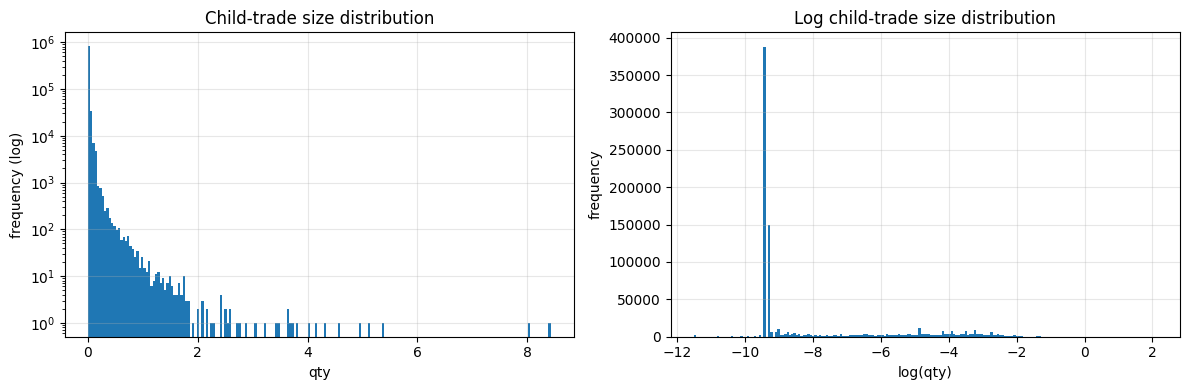

In [6]:
qty = trades["qty"].astype(float)
qty = qty[np.isfinite(qty) & (qty > 0)]
log_qty = np.log(qty)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(qty, bins=200, log=True)
axes[0].set_title("Child-trade size distribution")
axes[0].set_xlabel("qty")
axes[0].set_ylabel("frequency (log)")
axes[0].grid(True, alpha=0.3)

axes[1].hist(log_qty, bins=200)
axes[1].set_title("Log child-trade size distribution")
axes[1].set_xlabel("log(qty)")
axes[1].set_ylabel("frequency")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Same-Sign Run Analysis

This section tests the earlier observation that trades arrive in directional clusters rather than as an almost independent sign sequence.


In [7]:
run_df = trades[["aggr_sign", "qty", "notional", "ts"]].copy()
run_df = run_df[np.isfinite(run_df["aggr_sign"])].reset_index(drop=True)
run_df["new_run"] = run_df["aggr_sign"].ne(run_df["aggr_sign"].shift()).fillna(True)
run_df["run_id"] = run_df["new_run"].cumsum()

runs = (
    run_df.groupby("run_id", observed=False)
    .agg(
        sign=("aggr_sign", "first"),
        n_trades=("aggr_sign", "size"),
        qty_sum=("qty", "sum"),
        notional_sum=("notional", "sum"),
        start_ts=("ts", "first"),
        end_ts=("ts", "last"),
    )
    .reset_index(drop=True)
)
runs["duration_ms"] = (runs["end_ts"] - runs["start_ts"]).dt.total_seconds() * 1000.0

run_summary = pd.Series({
    "n_runs": len(runs),
    "mean_run_length": runs["n_trades"].mean(),
    "median_run_length": runs["n_trades"].median(),
    "p90_run_length": runs["n_trades"].quantile(0.9),
    "p99_run_length": runs["n_trades"].quantile(0.99),
    "max_run_length": runs["n_trades"].max(),
})

display(run_summary.to_frame("value"))
display(runs.head())


,value
n_runs,50021.000000
mean_run_length,17.352872
median_run_length,5.000000
p90_run_length,46.000000
p99_run_length,159.800000
max_run_length,1570.000000


,sign,n_trades,qty_sum,notional_sum,start_ts,end_ts,duration_ms
0,1.0,3,0.01015,677.050066,2026-02-23 01:00:04.958000+00:00,2026-02-23 01:00:05.037000+00:00,79.0
1,-1.0,8,0.00228,152.083020,2026-02-23 01:00:05.087000+00:00,2026-02-23 01:00:05.140000+00:00,53.0
2,1.0,1,0.00761,507.591338,2026-02-23 01:00:05.154000+00:00,2026-02-23 01:00:05.154000+00:00,0.0
3,-1.0,14,0.00802,534.917306,2026-02-23 01:00:05.554000+00:00,2026-02-23 01:00:06.387000+00:00,833.0
4,1.0,2,0.00065,43.349806,2026-02-23 01:00:06.877000+00:00,2026-02-23 01:00:07.178000+00:00,301.0


## Trade Count To Clock-Time Span

This section asks how much wall-clock time is typically needed for `T` consecutive trades.
For each window we measure the timestamp span from the first trade in the window to the last trade in the window.

That makes it easy to answer questions like:

- are `20` trades usually compressed into a couple of seconds,
- how often do `50` trades arrive within `10s`,
- how does the trade-count-to-time relationship change as `T` grows?

,T,windows,zero_span_share,mean_span_ms,median_span_ms,p05_span_ms,p10_span_ms,p25_span_ms,p75_span_ms,p90_span_ms,p99_span_ms,share_le_2s,share_le_5s,share_le_10s,share_le_30s,share_le_60s
0,10,867999,0.008891,830.364741,57.0,1.0,1.0,3.0,719.0,2527.2,9380.00,0.873730,0.960643,0.991597,0.999935,1.000000
1,20,867989,0.000000,1752.960699,449.0,3.0,6.0,40.0,2050.0,5054.0,15458.00,0.745529,0.898426,0.969454,0.999295,1.000000
2,50,867959,0.000000,4520.784438,2289.0,30.0,77.0,581.0,5797.0,11678.0,30615.42,0.466437,0.710985,0.872419,0.989338,0.999776
3,100,867909,0.000000,9134.046636,5517.0,159.0,582.0,2221.0,11943.0,21795.0,53241.00,0.230260,0.466808,0.695313,0.947221,0.994133
4,500,867509,0.000000,46049.972367,33115.0,5805.0,9657.0,17364.0,58190.0,100917.4,214861.00,0.018540,0.043049,0.105778,0.457714,0.763032


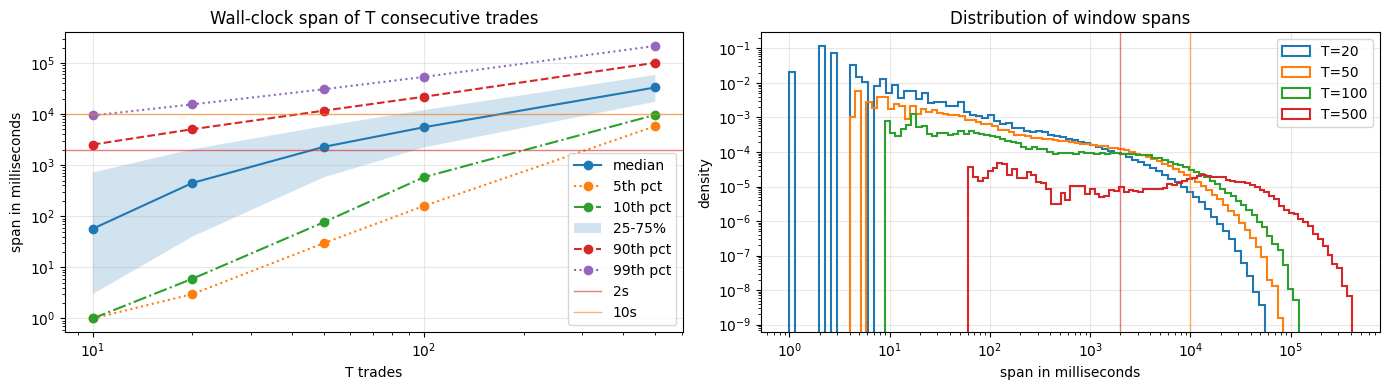

In [8]:
def rolling_window_span_ms(ts_values: pd.Series, T: int) -> np.ndarray:
    ts_ns = pd.to_datetime(ts_values, utc=True).astype("int64").to_numpy()
    span_ms = np.full(len(ts_ns), np.nan, dtype=float)
    if T <= 0:
        raise ValueError("T must be positive")
    if len(ts_ns) < T:
        return span_ms
    span_ms[T - 1 :] = (ts_ns[T - 1 :] - ts_ns[: -(T - 1)]) / 1_000_000.0
    return span_ms


SPAN_T_LIST = [10, 20, 50, 100, 500]
SPAN_THRESHOLD_MS_LIST = [2000, 5000, 10000, 30000, 60000]
span_rows = []
span_samples = {}

for T in SPAN_T_LIST:
    span_ms = rolling_window_span_ms(trades["ts"], T)
    finite = span_ms[np.isfinite(span_ms)]
    positive = finite[finite > 0]
    span_samples[T] = finite

    row = {
        "T": T,
        "windows": int(len(finite)),
        "zero_span_share": float((finite == 0).mean()) if len(finite) else np.nan,
        "mean_span_ms": float(np.mean(finite)) if len(finite) else np.nan,
        "median_span_ms": float(np.median(finite)) if len(finite) else np.nan,
        "p05_span_ms": float(np.quantile(finite, 0.05)) if len(finite) else np.nan,
        "p10_span_ms": float(np.quantile(finite, 0.10)) if len(finite) else np.nan,
        "p25_span_ms": float(np.quantile(finite, 0.25)) if len(finite) else np.nan,
        "p75_span_ms": float(np.quantile(finite, 0.75)) if len(finite) else np.nan,
        "p90_span_ms": float(np.quantile(finite, 0.90)) if len(finite) else np.nan,
        "p99_span_ms": float(np.quantile(finite, 0.99)) if len(finite) else np.nan,
    }
    for threshold_ms in SPAN_THRESHOLD_MS_LIST:
        row[f"share_le_{int(threshold_ms / 1000)}s"] = float((finite <= threshold_ms).mean()) if len(finite) else np.nan
    span_rows.append(row)

span_summary = pd.DataFrame(span_rows)
display(span_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(span_summary["T"], span_summary["median_span_ms"], marker="o", label="median")
axes[0].plot(span_summary["T"], span_summary["p05_span_ms"], marker="o", linestyle=":", label="5th pct")
axes[0].plot(span_summary["T"], span_summary["p10_span_ms"], marker="o", linestyle="-.", label="10th pct")
axes[0].fill_between(span_summary["T"], span_summary["p25_span_ms"], span_summary["p75_span_ms"], alpha=0.2, label="25-75%")
axes[0].plot(span_summary["T"], span_summary["p90_span_ms"], marker="o", linestyle="--", label="90th pct")
axes[0].plot(span_summary["T"], span_summary["p99_span_ms"], marker="o", linestyle=":", label="99th pct")
axes[0].axhline(2000, color="tab:red", linewidth=1, alpha=0.6, label="2s")
axes[0].axhline(10000, color="tab:orange", linewidth=1, alpha=0.6, label="10s")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Wall-clock span of T consecutive trades")
axes[0].set_xlabel("T trades")
axes[0].set_ylabel("span in milliseconds")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for T in [20, 50, 100, 500]:
    finite = span_samples[T]
    positive = finite[finite > 0]
    if len(positive) == 0:
        continue
    bins = np.geomspace(max(positive.min(), 1e-3), positive.max(), 80)
    axes[1].hist(positive, bins=bins, density=True, histtype="step", linewidth=1.5, label=f"T={T}")

axes[1].axvline(2000, color="tab:red", linewidth=1, alpha=0.6)
axes[1].axvline(10000, color="tab:orange", linewidth=1, alpha=0.6)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Distribution of window spans")
axes[1].set_xlabel("span in milliseconds")
axes[1].set_ylabel("density")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

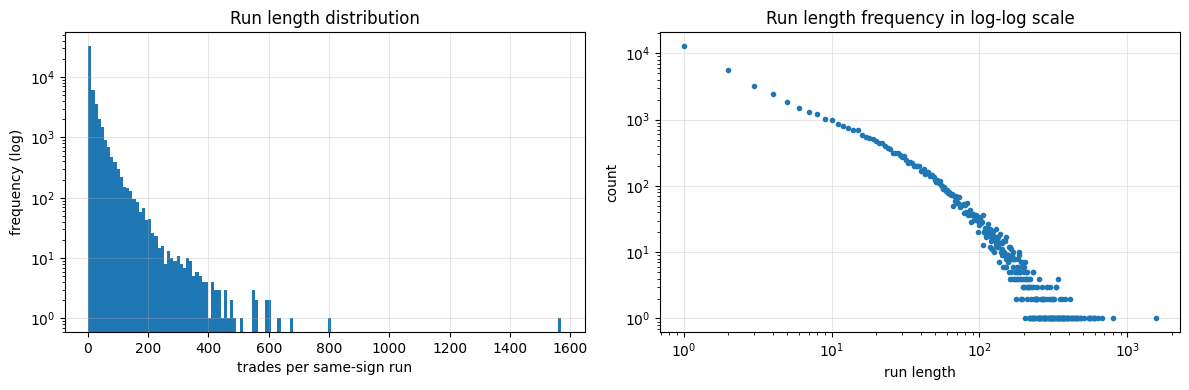

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(runs["n_trades"], bins=150, log=True)
axes[0].set_title("Run length distribution")
axes[0].set_xlabel("trades per same-sign run")
axes[0].set_ylabel("frequency (log)")
axes[0].grid(True, alpha=0.3)

run_counts = runs["n_trades"].value_counts().sort_index()
axes[1].plot(run_counts.index, run_counts.values, marker="o", linestyle="none", markersize=3)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Run length frequency in log-log scale")
axes[1].set_xlabel("run length")
axes[1].set_ylabel("count")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Raw-Trade Sign Imbalance Distribution

This is the windowed version of the same clustering diagnostic. For a window of `T` trades, the raw-trade sign imbalance is `I_T^(0) = sum epsilon_t`.

If the signs were close to i.i.d., the distribution would be concentrated near zero. Piles near the extremes indicate persistent same-sign flow.


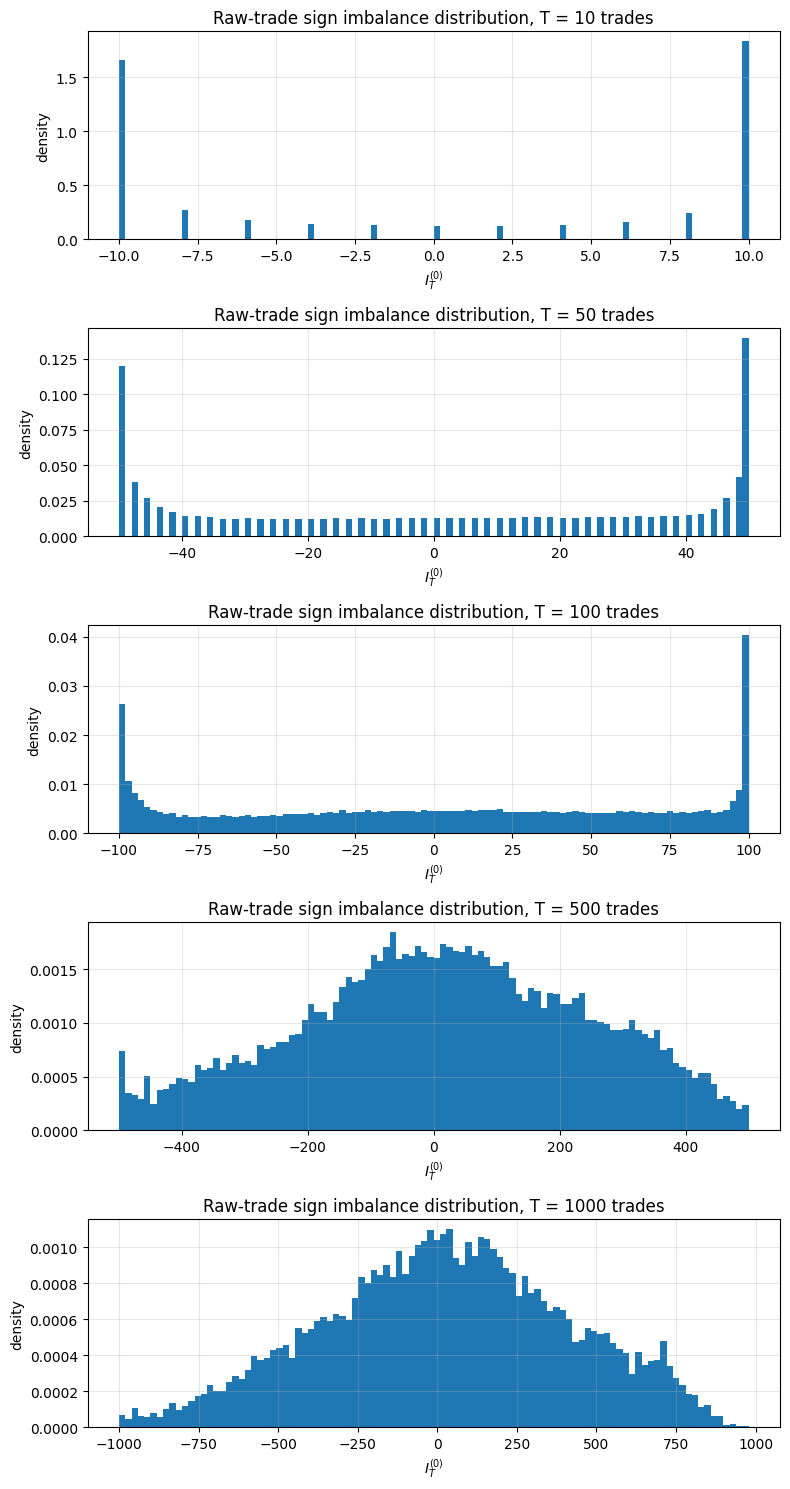

In [10]:
def rolling_sign_imbalance(sign_values: np.ndarray, T: int) -> np.ndarray:
    return pd.Series(sign_values).rolling(T).sum().to_numpy()


def plot_raw_sign_imbalance_histograms(trades_df: pd.DataFrame, T_list: list[int], sign_col: str = "aggr_sign", bins: int = 100) -> None:
    sign_values = trades_df[sign_col].to_numpy(dtype=float)

    fig, axes = plt.subplots(len(T_list), 1, figsize=(8, 3 * len(T_list)))
    if len(T_list) == 1:
        axes = [axes]

    for ax, T in zip(axes, T_list):
        I = rolling_sign_imbalance(sign_values, T)
        I = I[np.isfinite(I)]
        ax.hist(I, bins=bins, density=True)
        ax.set_title(f"Raw-trade sign imbalance distribution, T = {T} trades")
        ax.set_xlabel(r"$I_T^{(0)}$")
        ax.set_ylabel("density")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_raw_sign_imbalance_histograms(trades, T_list=[10, 50, 100, 500, 1000])


## Toy Example: Why The Two Diagnostics Differ

A run-length histogram counts each same-sign block once.
A sliding-window imbalance histogram counts overlapping windows, so long bursts contribute many extreme windows.


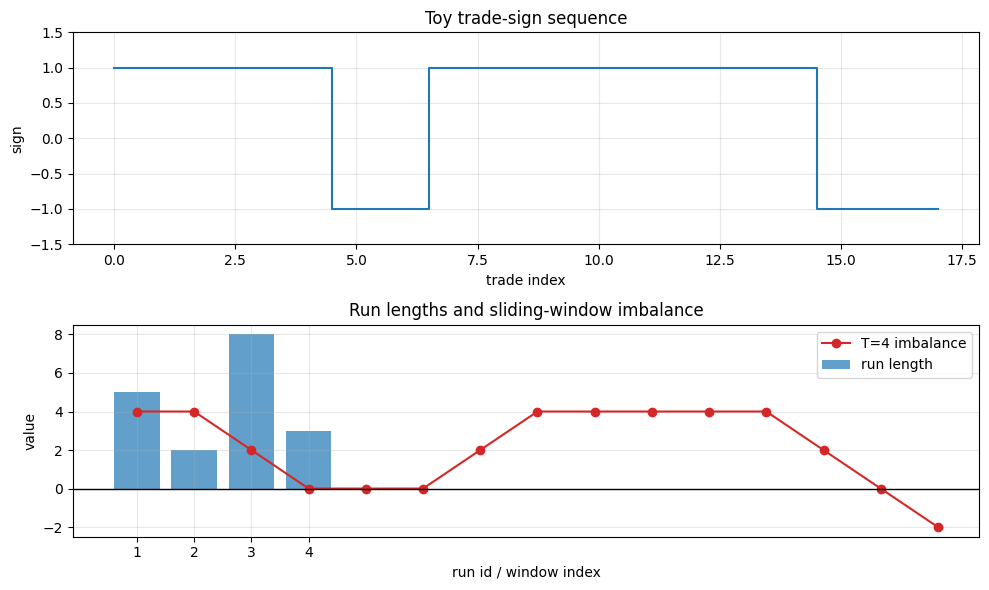

,run_id,sign,n_trades
0,1,1.0,5
1,2,-1.0,2
2,3,1.0,8
3,4,-1.0,3


Toy T=4 imbalance values: [4, 4, 2, 0, 0, 0, 2, 4, 4, 4, 4, 4, 2, 0, -2]


In [11]:
toy_sign = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1], dtype=float)

toy_run_df = pd.DataFrame({"aggr_sign": toy_sign})
toy_run_df["new_run"] = toy_run_df["aggr_sign"].ne(toy_run_df["aggr_sign"].shift()).fillna(True)
toy_run_df["run_id"] = toy_run_df["new_run"].cumsum()
toy_runs = toy_run_df.groupby("run_id", observed=False).agg(sign=("aggr_sign", "first"), n_trades=("aggr_sign", "size"))

toy_T = 4
toy_imbalance = rolling_sign_imbalance(toy_sign, toy_T)
toy_imbalance = toy_imbalance[np.isfinite(toy_imbalance)]

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].step(range(len(toy_sign)), toy_sign, where="mid")
axes[0].set_ylim(-1.5, 1.5)
axes[0].set_title("Toy trade-sign sequence")
axes[0].set_xlabel("trade index")
axes[0].set_ylabel("sign")
axes[0].grid(True, alpha=0.3)

axes[1].bar(toy_runs.index.astype(str), toy_runs["n_trades"], alpha=0.7, label="run length")
axes[1].plot(range(len(toy_imbalance)), toy_imbalance, marker="o", color="tab:red", label=f"T={toy_T} imbalance")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Run lengths and sliding-window imbalance")
axes[1].set_xlabel("run id / window index")
axes[1].set_ylabel("value")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(toy_runs.reset_index())
print(f"Toy T={toy_T} imbalance values:", toy_imbalance.astype(int).tolist())


Interpretation: the run-length histogram sees only four blocks here, but the sliding-window imbalance sees many overlapping windows from the long positive burst, so it can look extreme even when most run lengths are small.


## Sign Autocorrelation in Trade Time

If trade signs were nearly independent, the autocorrelation would collapse quickly toward zero. A slow decay supports the long-memory motivation behind the paper.


In [12]:
sign = trades["aggr_sign"].to_numpy(dtype=float)
sign = sign[np.isfinite(sign)]

def sign_autocorrelation(sign_values: np.ndarray, max_lag: int) -> pd.DataFrame:
    centered = sign_values - np.mean(sign_values)
    denom = np.dot(centered, centered)
    rows = []
    for lag in range(1, max_lag + 1):
        numer = np.dot(centered[:-lag], centered[lag:])
        rows.append({"lag": lag, "autocorr": numer / denom})
    return pd.DataFrame(rows)

acf_df = sign_autocorrelation(sign, max_lag=500)
display(acf_df.head(20))


,lag,autocorr
0,1,0.884662
1,2,0.828828
2,3,0.788762
3,4,0.754510
4,5,0.724496
5,6,0.697259
6,7,0.671433
7,8,0.647940
8,9,0.626153
9,10,0.606142


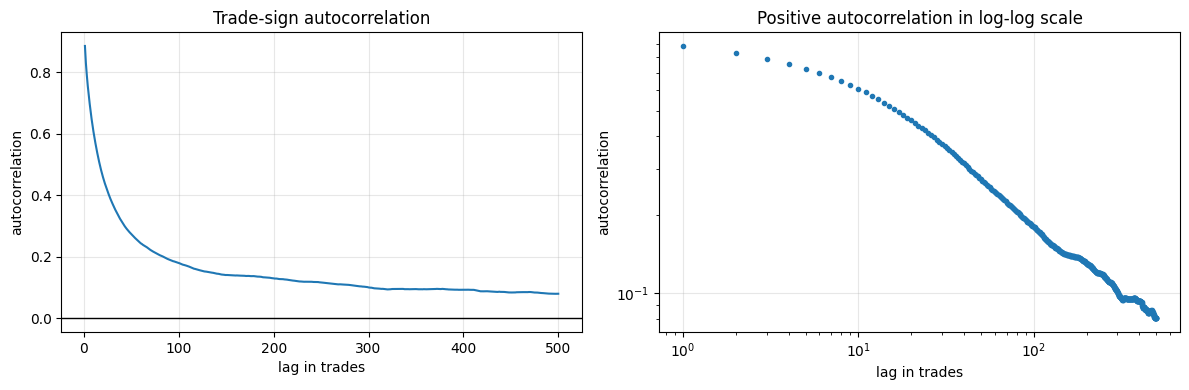

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(acf_df["lag"], acf_df["autocorr"])
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_title("Trade-sign autocorrelation")
axes[0].set_xlabel("lag in trades")
axes[0].set_ylabel("autocorrelation")
axes[0].grid(True, alpha=0.3)

acf_pos = acf_df[acf_df["autocorr"] > 0]
axes[1].plot(acf_pos["lag"], acf_pos["autocorr"], marker="o", linestyle="none", markersize=3)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Positive autocorrelation in log-log scale")
axes[1].set_xlabel("lag in trades")
axes[1].set_ylabel("autocorrelation")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Persistence by Size Bucket

This is a simple BTC-specific diagnostic: do larger child trades sit in different same-sign persistence regimes than smaller ones?


In [14]:
bucket_df = trades[["qty", "aggr_sign"]].copy()
bucket_df = bucket_df[np.isfinite(bucket_df["qty"]) & np.isfinite(bucket_df["aggr_sign"]) & (bucket_df["qty"] > 0)].copy()
bucket_codes = pd.qcut(bucket_df["qty"], q=5, duplicates="drop", labels=False)
bucket_df["size_bucket"] = "Q" + (bucket_codes + 1).astype(str)
bucket_df["same_as_prev"] = bucket_df["aggr_sign"].eq(bucket_df["aggr_sign"].shift())

bucket_summary = (
    bucket_df.groupby("size_bucket", observed=False)
    .agg(
        mean_qty=("qty", "mean"),
        median_qty=("qty", "median"),
        same_as_prev_rate=("same_as_prev", "mean"),
        count=("qty", "size"),
    )
    .reset_index()
)

display(bucket_summary)


,size_bucket,mean_qty,median_qty,same_as_prev_rate,count
0,Q1,0.000079,0.00008,0.986642,397670
1,Q2,0.000090,0.00009,0.963422,149242
2,Q3,0.001182,0.00050,0.858951,147509
3,Q4,0.042225,0.02365,0.893748,173587


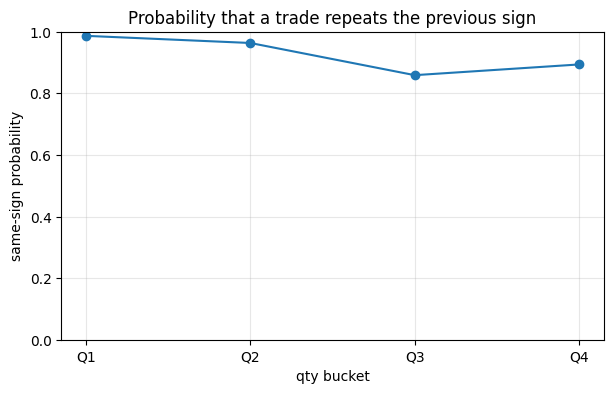

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(bucket_summary["size_bucket"].astype(str), bucket_summary["same_as_prev_rate"], marker="o")
plt.title("Probability that a trade repeats the previous sign")
plt.xlabel("qty bucket")
plt.ylabel("same-sign probability")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()


## How To Read These Diagnostics Together

We used Binance `BTCUSDC` data for `20260223`.

The plots are complementary rather than redundant:

- run lengths count same-sign blocks once,
- raw-trade sign imbalance counts overlapping `T`-trade windows,
- autocorrelation measures persistence as a function of lag,
- the size bucket view asks whether sign stickiness changes with trade size.

On this day the tape is strongly persistent, so short windows such as `T=10` often sit inside a directional burst and therefore look extreme in the imbalance histogram even though the run-length histogram is still concentrated at small values.

## Reading These Diagnostics

If the data shows long same-sign runs and a slowly decaying trade-sign autocorrelation, then BTCUSDC exhibits the kind of persistent order flow that motivates the paper's later imbalance scaling analysis.

The next notebook should build generalized imbalance directly on raw trades:

- `I_T^a = sum epsilon_t q_t^a`,
- several window sizes `T`,
- several exponents `a`,
- clipped and unclipped `qty` variants for robustness.
